# RETAIL ANALYTICS / MUC-01

## CATEGORY INTELLIGENCE

### Retail Product Performance — Jan to Jun 2026

> **Business Case**
>
> Turning transaction-level sales data into evidence for a quarterly supplier review.

---

### DATA SCOPE

**107K+ Transactions**  ·  **12 Stores**  ·  **5 Categories**  ·  **25 Products**  ·  **6 Months**

---

### ANALYTICAL OBJECTIVE

Identify where category performance is changing, which products are driving those changes, how discount levels relate to transaction performance, and when sales activity is strongest.

---

### DECISION OUTPUT

**Category Priority** → **Product Attention** → **Promotion Timing** → **Supplier Discussion**

---

*Calibo AI Academy | Phase 1 — Mini Use Case 01 | KLU*

---

# TEAM & WORK OWNERSHIP

| Member | Role | Primary Responsibility |
|---|---|---|
| **SAI TEJA** | **Data & Category Analyst** | Data inspection, category revenue trends, CBIM Problem Canvas |
| **GUNTIMADUGU REDDYPRASANNA** | **Product & Supplier Analyst** | Product performance, top/bottom products, supplier analysis |
| **Veerapaneni Sreya Angelin** | **Discount & Promotion Analyst** | Discount effectiveness, day-of-week analysis, promotion timing |
| **K Bonishira Akshaya** | **Business Strategy Analyst** | Monthly/category timing, Category Manager Briefing, project summary |

### TEAM APPROACH

Each member owned a major analytical area while contributing to the overall interpretation, review, and validation of the project.

---

# 1. Load and inspect the data

### a Environment & Data Loading

The analysis begins by establishing the Python environment and loading the transaction-level retail dataset.

At this stage, the objective is only to confirm that the required analytical libraries are available and that the provided dataset can be accessed successfully.

**Data source:** `MUC01_Retail_Sales_Dataset.csv`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


### b Loading the Transaction Dataset

The provided CSV file contains transaction-level sales records for the six-month analysis period.

The dataset is loaded into a Pandas DataFrame so that it can be profiled and validated before any transformation or visualization is performed.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### c Initial Data Preview

A small sample of the dataset is displayed below to verify that the records and expected business fields have been loaded correctly.

In [3]:
df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


### d Dataset Size and Structure
#### Why are we checking this?
We check the dataset size and structure to understand how many transaction records and business fields are available and whether the columns have appropriate data types for analysis.

In [4]:
df.shape

(107836, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB



**we found:**

The dataset contains 107,836 transaction records across 10 fields. The dataset includes the transaction, store, category, product, sales and discount information required for the analysis.

### e Missing Values Check
**Why are we checking this?**

Missing values can affect calculations and comparisons. We therefore check whether any important business fields contain incomplete records.

In [6]:
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_summary

,Column,Missing Values
0,transaction_id,0
1,date,0
2,store_id,0
3,store_city,0
4,category,0
5,product_name,0
6,units_sold,0
7,unit_price,0
8,revenue,0
9,discount_pct,0


**What we found**

All 10 columns contain 0 missing values, so the dataset is complete for the fields required in this analysis.

### f Unique Products and Categories
**Why are we checking this?**

The analysis focuses on category and product performance, so we first identify how many categories and individual products are represented in the dataset.

In [7]:
print("Unique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())

Unique products: 25
Unique categories: 5


### g Descriptive Statistics
**Why are we checking this?**

Descriptive statistics provide an initial view of transaction volume, pricing, revenue and discount behaviour before category-level analysis begins

In [10]:
df[["units_sold", "unit_price", "revenue", "discount_pct"]].describe().T

,count,mean,std,min,25%,50%,75%,max
units_sold,107836.0,2.583488,1.471616,1.00,1.0000,2.000,3.0000,13.00
unit_price,107836.0,1778.097787,5053.631792,50.02,274.8275,488.450,1039.5225,44990.14
revenue,107836.0,4263.920924,14243.244169,40.04,467.7725,1034.615,2473.3350,355090.88
discount_pct,107836.0,7.228152,6.730445,0.00,0.0000,5.000,10.0000,20.00


### What We Found

**1. Revenue varies significantly between transactions.**  
The average transaction revenue is about **₹4,264**, while the median (50%) is about **₹1,035**. This shows that some high-value transactions increase the average, so we need to examine which products and categories are contributing to higher revenue.

**2. Most transactions involve small quantities.**  
The median (50%) transaction contains **2 units**, and 75% of transactions contain **3 units or fewer**. This shows that most transactions involve small quantities, so product price and the products being sold are important when understanding revenue performance.

---------


# 2 Category Revenue Trend Over Time

The Category Manager needs to understand how each category is performing over the six-month period. By comparing monthly revenue across all five categories, we can identify categories that are declining, growing, or remaining relatively stable.

### a Preparing the time dimension
### Why are we checking this?

The transaction date is currently stored as text. We need to convert it into a proper date format so that we can create monthly and day-of-week dimensions for the analysis.

In [11]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date"].dt.day_name()

print("Date dimension prepared successfully.")

Date dimension prepared successfully.


### What We Found

The date field has been successfully converted to a proper datetime format. Monthly and day-of-week fields are now available for the time-based analysis.

### b Monthly Revenue by Category
#### Why are we checking this?

We need to calculate the total revenue generated by each category in each month. This allows us to compare category performance consistently from January to June.

In [13]:
monthly_category_revenue = (
    df.groupby(["month", "category"])["revenue"]
      .sum()
      .reset_index()
)

#monthly_category_revenue.head(10)
monthly_category_revenue

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


### What We Found

The monthly revenue results show that **Electronics generates the highest revenue across all six months**, but its revenue shows a clear downward movement from January to June. **Apparel shows the opposite pattern**, increasing toward June, while **Grocery remains relatively stable** throughout the period. Home & Kitchen and Personal Care show smaller fluctuations compared with Electronics and Apparel.

### c Category Revenue Matrix
#### Why are we checking this?

The monthly revenue table contains one row for each month and category. Reshaping the results into a category-by-month matrix makes it easier to compare all five categories across the six-month period.

In [14]:
category_revenue_matrix = (
    monthly_category_revenue
    .pivot(index="month", columns="category", values="revenue")
)

category_revenue_matrix

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


### What We Found

The category revenue matrix makes the six-month movement easy to compare. Electronics shows the clearest downward pattern, while Apparel shows a steady improvement toward June. Grocery remains relatively stable, whereas Home & Kitchen declines overall and Personal Care shows smaller fluctuations.

### d Category Revenue Trend
### Why are we checking this?

A line chart helps us clearly see how the revenue of all five categories changes from January to June. This makes it easier to identify categories that are growing, declining, or remaining stable.

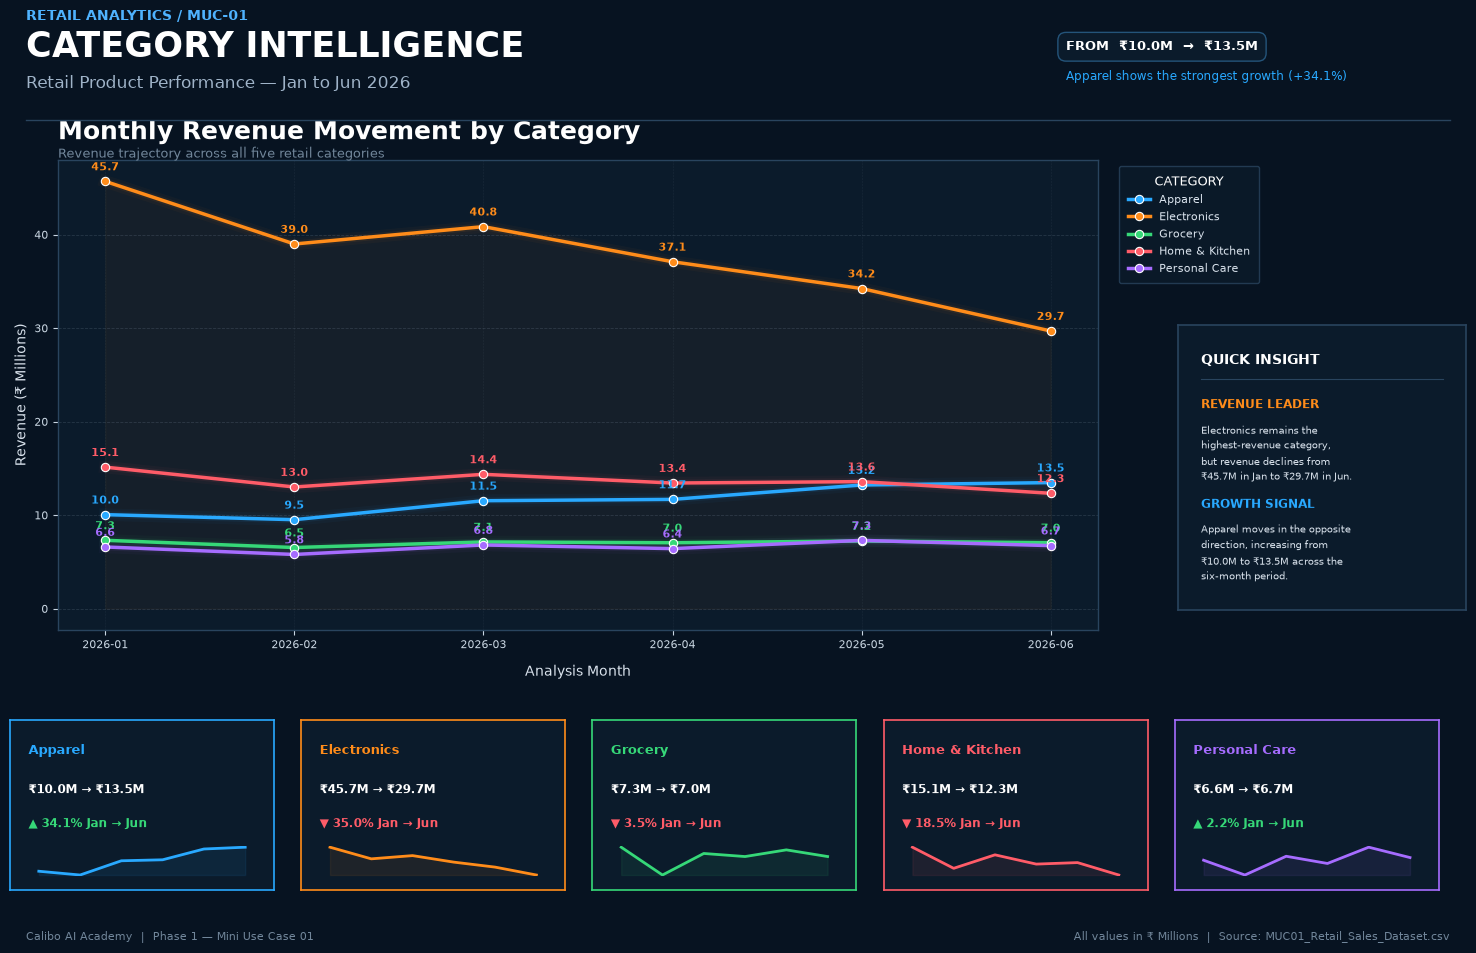

In [15]:
# ============================================================
# CATEGORY INTELLIGENCE — EXECUTIVE DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

months = category_revenue_matrix.index
categories = category_revenue_matrix.columns

revenue_millions = category_revenue_matrix / 1_000_000

# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

colors = {
    "Apparel": "#29A9FF",
    "Electronics": "#FF8C1A",
    "Grocery": "#36D878",
    "Home & Kitchen": "#FF5C68",
    "Personal Care": "#A66CFF"
}

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(16, 10),
    facecolor="#071321"
)

# ============================================================
# HEADER
# ============================================================

fig.text(
    0.055, 0.955,
    "RETAIL ANALYTICS / MUC-01",
    fontsize=10,
    color="#4FB3FF",
    fontweight="bold"
)

fig.text(
    0.055, 0.918,
    "CATEGORY INTELLIGENCE",
    fontsize=25,
    color="white",
    fontweight="bold"
)

fig.text(
    0.055, 0.887,
    "Retail Product Performance — Jan to Jun 2026",
    fontsize=12,
    color="#9FB3C8"
)

# ------------------------------------------------------------
# TOP RIGHT BUSINESS SIGNAL
# ------------------------------------------------------------

apparel_start = revenue_millions["Apparel"].iloc[0]
apparel_end = revenue_millions["Apparel"].iloc[-1]

apparel_growth = (
    (apparel_end - apparel_start) /
    apparel_start
) * 100

fig.text(
    0.705,
    0.925,
    f"FROM  ₹{apparel_start:.1f}M  →  ₹{apparel_end:.1f}M",
    fontsize=9,
    color="white",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.65",
        facecolor="#0B1B2B",
        edgecolor="#24547A",
        linewidth=1
    )
)

fig.text(
    0.705,
    0.895,
    f"Apparel shows the strongest growth (+{apparel_growth:.1f}%)",
    fontsize=8.5,
    color="#29A9FF"
)

# Header line
fig.lines.append(
    plt.Line2D(
        [0.055, 0.945],
        [0.855, 0.855],
        transform=fig.transFigure,
        color="#29445E",
        linewidth=1
    )
)

# ============================================================
# MAIN CHART
# ============================================================

ax = fig.add_axes(
    [0.075, 0.345, 0.65, 0.47]
)

ax.set_facecolor("#0B1B2B")

# ------------------------------------------------------------
# CATEGORY TREND LINES
# ------------------------------------------------------------

for category in categories:

    values = revenue_millions[category].values
    color = colors[category]

    # Glow
    ax.plot(
        months,
        values,
        color=color,
        linewidth=9,
        alpha=0.035,
        zorder=1
    )

    ax.plot(
        months,
        values,
        color=color,
        linewidth=5,
        alpha=0.07,
        zorder=2
    )

    # Main line
    ax.plot(
        months,
        values,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=6,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label=category,
        zorder=4
    )

    # Data labels
    for x, y in zip(months, values):

        ax.annotate(
            f"{y:.1f}",
            (x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color=color,
            zorder=5
        )

# ------------------------------------------------------------
# ELECTRONICS HIGHLIGHT
# ------------------------------------------------------------

electronics = revenue_millions["Electronics"].values

ax.fill_between(
    months,
    electronics,
    0,
    color="#FF8C1A",
    alpha=0.045,
    zorder=0
)

# ============================================================
# CHART FORMATTING
# ============================================================

ax.set_title(
    "Monthly Revenue Movement by Category",
    fontsize=18,
    fontweight="bold",
    color="white",
    loc="left",
    pad=15
)

ax.text(
    0,
    1.005,
    "Revenue trajectory across all five retail categories",
    transform=ax.transAxes,
    fontsize=9,
    color="#71869A"
)

ax.set_xlabel(
    "Analysis Month",
    fontsize=10,
    color="#D9E2EC",
    labelpad=10
)

ax.set_ylabel(
    "Revenue (₹ Millions)",
    fontsize=10,
    color="#D9E2EC"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color="#9FB3C8"
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.4,
    alpha=0.10,
    color="#9FB3C8"
)

for spine in ax.spines.values():
    spine.set_color("#29445E")
    spine.set_linewidth(1)

ax.tick_params(
    colors="#C9D6E2",
    labelsize=8
)

# ============================================================
# CATEGORY LEGEND
# ============================================================

legend = ax.legend(
    title="CATEGORY",
    loc="upper left",
    bbox_to_anchor=(1.015, 1.0),
    frameon=True,
    facecolor="#0B1B2B",
    edgecolor="#29445E",
    fontsize=8,
    title_fontsize=9,
    borderpad=0.8
)

legend.get_title().set_color("white")

for text in legend.get_texts():
    text.set_color("#D9E2EC")

# ============================================================
# QUICK INSIGHT PANEL — CLEAN VERSION
# ============================================================

insight_ax = fig.add_axes(
    [0.775, 0.365, 0.18, 0.285],
    facecolor="#0B1B2B"
)

# Panel border
for spine in insight_ax.spines.values():
    spine.set_color("#29445E")
    spine.set_linewidth(1.2)

insight_ax.set_xlim(0, 1)
insight_ax.set_ylim(0, 1)

insight_ax.set_xticks([])
insight_ax.set_yticks([])

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

insight_ax.text(
    0.08,
    0.90,
    "QUICK INSIGHT",
    fontsize=10,
    fontweight="bold",
    color="white",
    va="top",
    transform=insight_ax.transAxes
)

# Separator
insight_ax.plot(
    [0.08, 0.92],
    [0.81, 0.81],
    color="#29445E",
    linewidth=0.8,
    transform=insight_ax.transAxes
)

# ------------------------------------------------------------
# INSIGHT 1 — HEADING
# ------------------------------------------------------------

insight_ax.text(
    0.08,
    0.74,
    "REVENUE LEADER",
    fontsize=8.5,
    fontweight="bold",
    color="#FF8C1A",
    va="top",
    transform=insight_ax.transAxes
)

# Insight 1 text
insight_ax.text(
    0.08,
    0.66,
    "Electronics remains the\n"
    "highest-revenue category,\n"
    "but revenue declines from\n"
    "₹45.7M in Jan to ₹29.7M in Jun.",
    fontsize=7.5,
    color="#D9E2EC",
    va="top",
    linespacing=1.5,
    transform=insight_ax.transAxes
)

# ------------------------------------------------------------
# INSIGHT 2 — HEADING
# ------------------------------------------------------------

insight_ax.text(
    0.08,
    0.39,
    "GROWTH SIGNAL",
    fontsize=8.5,
    fontweight="bold",
    color="#29A9FF",
    va="top",
    transform=insight_ax.transAxes
)

# Insight 2 text
insight_ax.text(
    0.08,
    0.31,
    "Apparel moves in the opposite\n"
    "direction, increasing from\n"
    "₹10.0M to ₹13.5M across the\n"
    "six-month period.",
    fontsize=7.5,
    color="#D9E2EC",
    va="top",
    linespacing=1.5,
    transform=insight_ax.transAxes
)

# ============================================================
# CATEGORY SUMMARY CARDS
# ============================================================

card_y = 0.085
card_width = 0.165
card_height = 0.17

start_x = 0.045
gap = 0.017

for i, category in enumerate(categories):

    x = start_x + i * (card_width + gap)

    card = fig.add_axes(
        [x, card_y, card_width, card_height],
        facecolor="#0B1B2B"
    )

    for spine in card.spines.values():
        spine.set_color(colors[category])
        spine.set_linewidth(1.2)

    card.set_xticks([])
    card.set_yticks([])

    values = revenue_millions[category].values

    start_value = values[0]
    end_value = values[-1]

    change_pct = (
        (end_value - start_value) /
        start_value
    ) * 100

    # Category
    card.text(
        0.07,
        0.80,
        category,
        fontsize=9,
        fontweight="bold",
        color=colors[category],
        transform=card.transAxes
    )

    # Revenue
    card.text(
        0.07,
        0.57,
        f"₹{start_value:.1f}M → ₹{end_value:.1f}M",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        transform=card.transAxes
    )

    # Change
    if change_pct >= 0:
        symbol = "▲"
        change_color = "#36D878"
    else:
        symbol = "▼"
        change_color = "#FF5C68"

    card.text(
        0.07,
        0.37,
        f"{symbol} {abs(change_pct):.1f}% Jan → Jun",
        fontsize=8.5,
        fontweight="bold",
        color=change_color,
        transform=card.transAxes
    )

    # --------------------------------------------------------
    # MINI SPARKLINE
    # --------------------------------------------------------

    spark_ax = card.inset_axes(
        [0.07, 0.08, 0.86, 0.18]
    )

    spark_ax.set_facecolor("#0B1B2B")

    spark_ax.plot(
        range(len(values)),
        values,
        color=colors[category],
        linewidth=2
    )

    spark_ax.fill_between(
        range(len(values)),
        values,
        min(values),
        color=colors[category],
        alpha=0.08
    )

    spark_ax.set_xticks([])
    spark_ax.set_yticks([])

    for spine in spark_ax.spines.values():
        spine.set_visible(False)

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.055,
    0.035,
    "Calibo AI Academy  |  Phase 1 — Mini Use Case 01",
    fontsize=8,
    color="#71869A"
)

fig.text(
    0.945,
    0.035,
    "All values in ₹ Millions  |  Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color="#71869A",
    ha="right"
)

# ============================================================
# DISPLAY
# ============================================================

plt.show()

### What We Found

**Electronics shows the steepest decline and should be a key focus during the supplier review.** Its revenue decreased from **₹45.7M in January to ₹29.7M in June**, representing a **35.0% decline** over the six-month period.

**Grocery has been the most consistent performer.** Its revenue changed from **₹7.3M in January to ₹7.0M in June**, a relatively small **3.5% decline**, with monthly revenue remaining within a narrow range.

-------------------

## 3 Top and Bottom Products by Category
### Why are we checking this?

Category-level revenue shows where performance is changing, but the supplier review also requires visibility into the products responsible for that performance.

The analysis below ranks products by total six-month revenue and identifies the Top 2 and Bottom 2 products within each category for supplier-level discussion.

### a Calculate Product Revenue
We want to know:

How much revenue did each individual product generate during the complete six months?

In [17]:
product_revenue = (
    df.groupby(["category", "product_name"])["revenue"]
      .sum()
      .reset_index()
)
product_revenue

,category,product_name,revenue
0,Apparel,Formal Shirt,13748976.91
1,Apparel,Jeans,13862749.46
2,Apparel,Kurta,13606747.03
3,Apparel,Saree,14161864.63
4,Apparel,T-Shirt,14099251.65
5,Electronics,Headphones,47696053.99
6,Electronics,Laptop,46551078.39
7,Electronics,Mobile Phone,45654037.41
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93


### What We Found

The product-level results show that revenue is distributed differently across products within each category. For example, in Electronics, **Headphones generated the highest six-month revenue at about ₹47.70M**, followed by **Laptop at about ₹46.55M**. This shows why product-level analysis is useful for identifying the main revenue drivers and products that may need further attention.

### b Top 2 and Bottom 2 Products
#### Why are we checking this?

We need to identify the two highest-revenue and two lowest-revenue products within each category. This helps the Category Manager understand which products are driving category revenue and which products may need further supplier or assortment review.

In [21]:
top_bottom_products = []

for category in product_revenue["category"].unique():

    category_products = product_revenue[
        product_revenue["category"] == category
    ]

    top_2 = category_products.sort_values(
        "revenue", ascending=False
    ).head(2).copy()

    top_2["Performance Group"] = "Top 2"

    bottom_2 = category_products.sort_values(
        "revenue", ascending=False
    ).tail(2).copy()

    bottom_2["Performance Group"] = "Bottom 2"

    top_bottom_products.append(top_2)
    top_bottom_products.append(bottom_2)

top_bottom_products = pd.concat(
    top_bottom_products,
    ignore_index=True
)

top_bottom_products

,category,product_name,revenue,Performance Group
0,Apparel,Saree,14161864.63,Top 2
1,Apparel,T-Shirt,14099251.65,Top 2
2,Apparel,Formal Shirt,13748976.91,Bottom 2
3,Apparel,Kurta,13606747.03,Bottom 2
4,Electronics,Headphones,47696053.99,Top 2
5,Electronics,Laptop,46551078.39,Top 2
6,Electronics,Tablet,44744388.93,Bottom 2
7,Electronics,Smart TV,41882166.21,Bottom 2
8,Grocery,Rice (5kg),8562171.86,Top 2
9,Grocery,Dal (1kg),8488303.64,Top 2


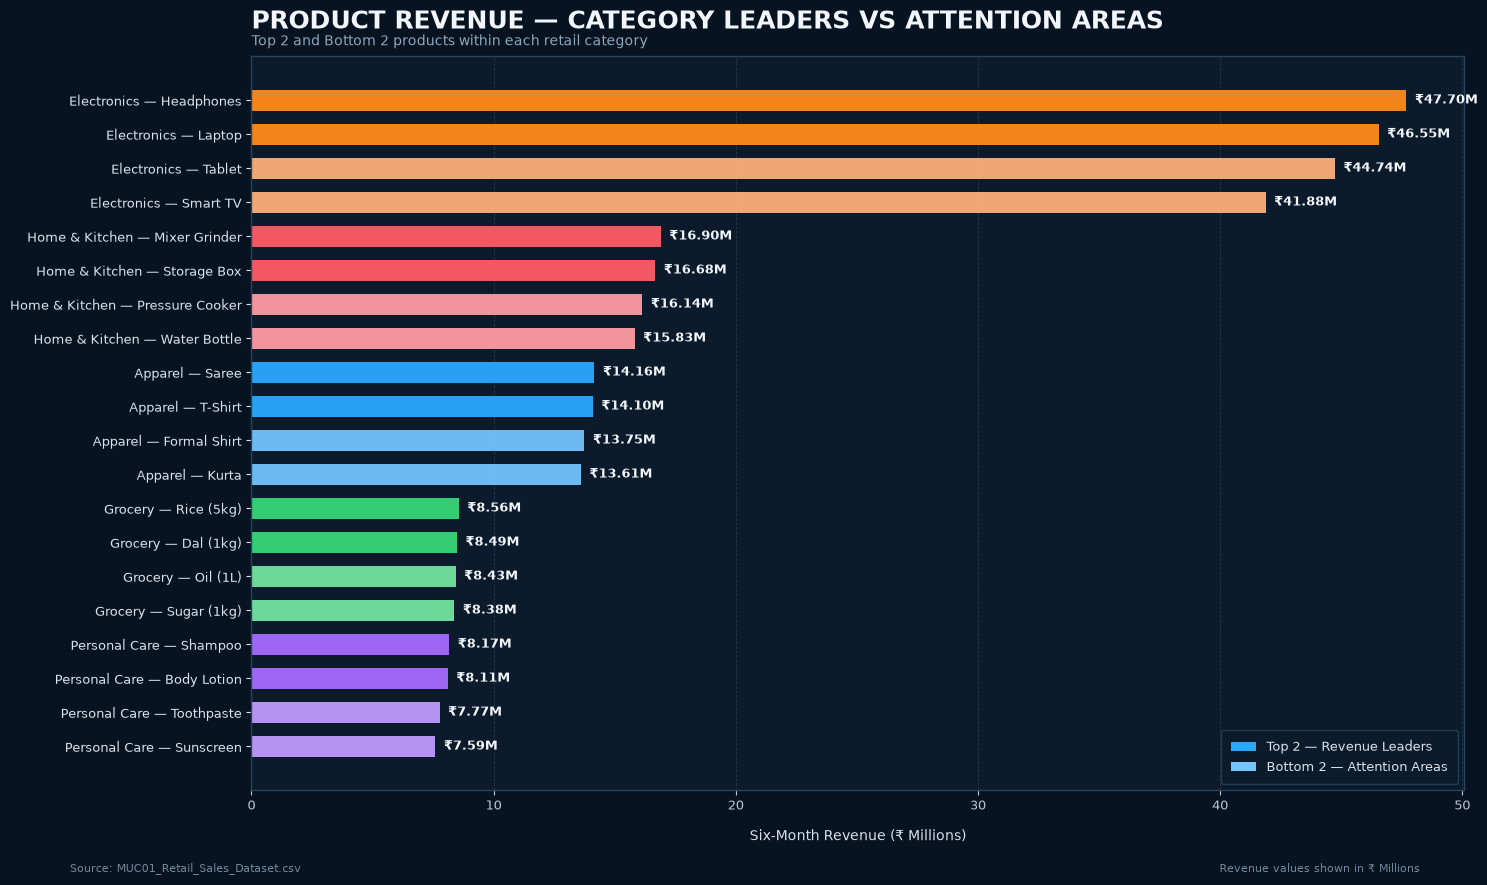

In [22]:
# ============================================================
# PRODUCT PERFORMANCE — CATEGORY LEADERS VS ATTENTION AREAS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# PREPARE DATA FOR VISUALIZATION
# ------------------------------------------------------------

plot_data = top_bottom_products.copy()

# Convert revenue to ₹ Millions
plot_data["Revenue (₹M)"] = plot_data["revenue"] / 1_000_000

# Create readable product labels
plot_data["Product Label"] = (
    plot_data["category"] + " — " + plot_data["product_name"]
)

# Sort for horizontal bar chart
plot_data = plot_data.sort_values(
    "Revenue (₹M)",
    ascending=True
)

# ------------------------------------------------------------
# COLOR SYSTEM
# ------------------------------------------------------------

category_colors = {
    "Apparel": "#29A9FF",
    "Electronics": "#FF8C1A",
    "Grocery": "#36D878",
    "Home & Kitchen": "#FF5C68",
    "Personal Care": "#A66CFF"
}

soft_colors = {
    "Apparel": "#73C4FF",
    "Electronics": "#FFB07A",
    "Grocery": "#72E5A0",
    "Home & Kitchen": "#FF9BA2",
    "Personal Care": "#C09AFF"
}

# ------------------------------------------------------------
# ASSIGN COLORS
# ------------------------------------------------------------

bar_colors = []

for _, row in plot_data.iterrows():

    category = row["category"]

    if row["Performance Group"] == "Top 2":
        bar_colors.append(category_colors[category])
    else:
        bar_colors.append(soft_colors[category])

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 9),
    facecolor="#071321"
)

ax.set_facecolor("#0B1B2B")

# ------------------------------------------------------------
# BARS
# ------------------------------------------------------------

bars = ax.barh(
    plot_data["Product Label"],
    plot_data["Revenue (₹M)"],
    color=bar_colors,
    height=0.62,
    alpha=0.95
)

# ------------------------------------------------------------
# VALUE LABELS
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    plot_data["Revenue (₹M)"]
):

    ax.text(
        bar.get_width() + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:.2f}M",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#F2F6FA"
    )

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "PRODUCT REVENUE — CATEGORY LEADERS VS ATTENTION AREAS",
    fontsize=18,
    fontweight="bold",
    color="#F2F6FA",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.015,
    "Top 2 and Bottom 2 products within each retail category",
    transform=ax.transAxes,
    fontsize=10,
    color="#8FA6BB"
)

# ============================================================
# AXIS
# ============================================================

ax.set_xlabel(
    "Six-Month Revenue (₹ Millions)",
    fontsize=10,
    color="#D9E2EC",
    labelpad=12
)

ax.set_ylabel("")

ax.tick_params(
    axis="x",
    colors="#B8C7D6",
    labelsize=9
)

ax.tick_params(
    axis="y",
    colors="#D9E2EC",
    labelsize=9
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color="#9FB3C8"
)

ax.set_axisbelow(True)

# ============================================================
# BORDER
# ============================================================

for spine in ax.spines.values():

    spine.set_color("#29445E")
    spine.set_linewidth(1)

# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor="#29A9FF",
        label="Top 2 — Revenue Leaders"
    ),

    Patch(
        facecolor="#73C4FF",
        label="Bottom 2 — Attention Areas"
    )
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    facecolor="#0B1B2B",
    edgecolor="#29445E",
    fontsize=9,
    borderpad=0.8
)

for text in legend.get_texts():
    text.set_color("#D9E2EC")

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.05,
    0.025,
    "Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color="#71869A"
)

fig.text(
    0.95,
    0.025,
    "Revenue values shown in ₹ Millions",
    fontsize=8,
    color="#71869A",
    ha="right"
)

# ============================================================
# DISPLAY
# ============================================================

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

### What We Found

Electronics has the highest-revenue products in the analysis, with **Headphones generating ₹47.70M** and **Laptop generating ₹46.55M** over six months. The lower-ranked Electronics products, Tablet and Smart TV, also generate substantial revenue at **₹44.74M** and **₹41.88M**. This shows that Electronics is an important revenue contributor, but its products should be examined alongside the category's overall **35.0% decline** identified in this Step 

### Supplier Challenge Recommendation

The **Electronics category** should be a key focus during the supplier review. It generated the highest category revenue, but also experienced the **steepest decline of 35.0%**, falling from **₹45.7M in January to ₹29.7M in June**. At the product level, Headphones and Laptop remain strong revenue contributors, while Tablet and Smart TV are the lower-ranked Electronics products. The supplier should therefore be asked to explain the decline in Electronics performance and provide a plan to improve category momentum.

-------------

## 4 Discount Effectiveness Analysis 
### Why are we checking this?

We want to compare transaction performance at different discount levels. Grouping transactions into discount brackets makes it easier to see whether higher discounts are associated with higher revenue or higher sales volume.

In [23]:
discount_bins = [-0.1, 0, 5, 10, 15, 20, float("inf")]

discount_labels = [
    "0%",
    "5%",
    "10%",
    "15%",
    "20%",
    "25%+"
]

df["discount_group"] = pd.cut(
    df["discount_pct"],
    bins=discount_bins,
    labels=discount_labels
)

df["discount_group"].value_counts().sort_index()

discount_group
0%      36033
5%      23922
10%     23810
15%     11935
20%     12136
25%+        0
Name: count, dtype: int64

### What We Found

The dataset contains transactions across discount levels from **0% to 20%**, with **no transactions above 20%**. The largest group is the **0% discount level with 36,033 transactions**, providing a substantial baseline for comparison with discounted transactions.

### a Calculate Average Revenue and Units Sold
### Why are we checking this?

We compare **average revenue per transaction** and **average units sold** for each discount level. Revenue per transaction shows the value generated from a typical transaction, while units sold shows whether higher discounts are associated with larger purchase quantities.


In [24]:
discount_analysis = (
    df.groupby("discount_group", observed=False)
      .agg(
          Avg_Revenue_Per_Transaction=("revenue", "mean"),
          Avg_Units_Sold=("units_sold", "mean"),
          Transaction_Count=("transaction_id", "count")
      )
      .reset_index()
)

discount_analysis

,discount_group,Avg_Revenue_Per_Transaction,Avg_Units_Sold,Transaction_Count
0,0%,4685.654340,2.586018,36033
1,5%,4303.730312,2.591882,23922
2,10%,4005.545405,2.566401,23810
3,15%,4069.164408,2.595140,11935
4,20%,3631.727433,2.581493,12136
5,25%+,NaN,NaN,0


### What We Found

Average revenue per transaction generally decreases as discount depth increases. It falls from **₹4,685.65 at 0% discount to ₹3,631.73 at 20% discount**, a decrease of about **22.5%**. At the same time, average units sold remains almost unchanged at around **2.6 units per transaction**, suggesting that higher discounts are not associated with a meaningful increase in purchase quantity.

### b Discount Revenue Response
### Why are we checking this?

The bar chart makes the relationship between discount depth and average transaction revenue easier to compare. It helps the Category Manager assess whether deeper discounts are associated with stronger transaction value.

In [26]:
plot_discount = discount_analysis.copy()

plot_discount = plot_discount.rename(
    columns={
        "discount_group": "Discount Level",
        "Avg_Revenue_Per_Transaction": "Avg Revenue / Transaction (₹)",
        "Avg_Units_Sold": "Avg Units Sold",
        "Transaction_Count": "Transaction Count"
    }
)

plot_discount

,Discount Level,Avg Revenue / Transaction (₹),Avg Units Sold,Transaction Count
0,0%,4685.654340,2.586018,36033
1,5%,4303.730312,2.591882,23922
2,10%,4005.545405,2.566401,23810
3,15%,4069.164408,2.595140,11935
4,20%,3631.727433,2.581493,12136
5,25%+,NaN,NaN,0


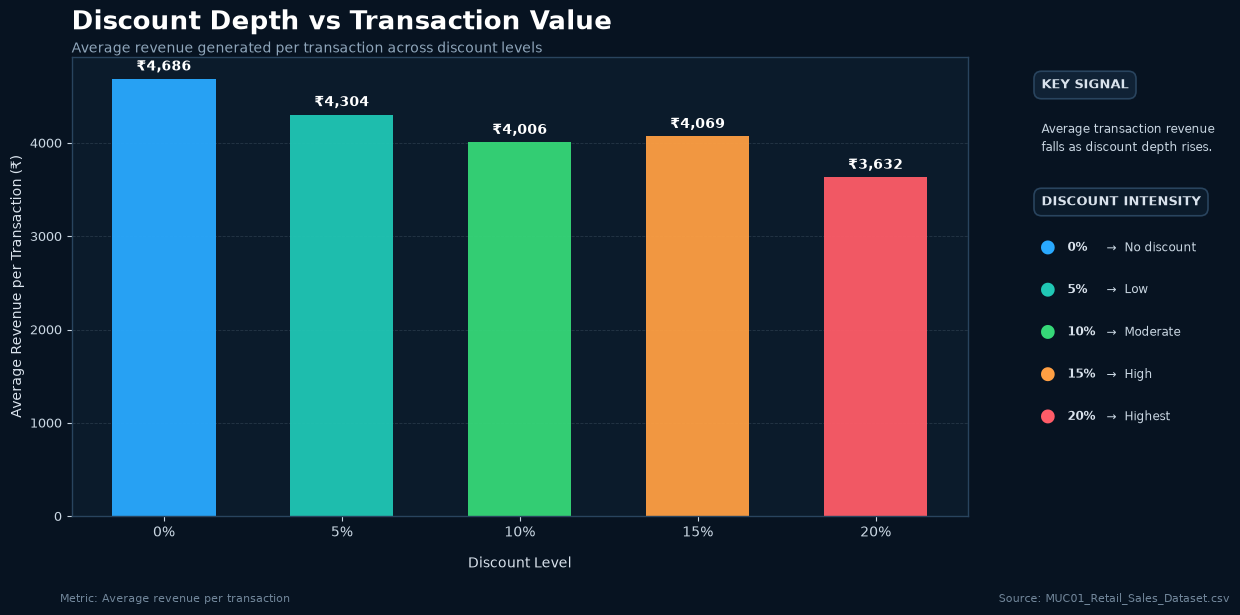

In [27]:
# ============================================================
# DISCOUNT EFFECTIVENESS — DISCOUNT INTENSITY VISUAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 6.5),
    facecolor="#071321"
)

ax.set_facecolor("#0B1B2B")

# ------------------------------------------------------------
# DISCOUNT COLORS
# ------------------------------------------------------------

discount_colors = [
    "#29A9FF",   # 0%
    "#20C7B5",   # 5%
    "#36D878",   # 10%
    "#FF9F43",   # 15%
    "#FF5C68"    # 20%
]

# ------------------------------------------------------------
# BARS
# ------------------------------------------------------------

bars = ax.bar(
    plot_discount["Discount Level"],
    plot_discount["Avg Revenue / Transaction (₹)"],
    color=discount_colors[:len(plot_discount)],
    width=0.58,
    alpha=0.95
)

# ------------------------------------------------------------
# VALUE LABELS
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    plot_discount["Avg Revenue / Transaction (₹)"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 55,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Discount Depth vs Transaction Value",
    fontsize=19,
    fontweight="bold",
    color="white",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.01,
    "Average revenue generated per transaction across discount levels",
    transform=ax.transAxes,
    fontsize=10,
    color="#8FA6BB"
)

# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    "Discount Level",
    fontsize=10,
    color="#D9E2EC",
    labelpad=12
)

ax.set_ylabel(
    "Average Revenue per Transaction (₹)",
    fontsize=10,
    color="#D9E2EC"
)

ax.tick_params(
    axis="x",
    colors="#C9D6E2",
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors="#C9D6E2",
    labelsize=9
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color="#9FB3C8"
)

ax.set_axisbelow(True)

# ============================================================
# BORDER
# ============================================================

for spine in ax.spines.values():
    spine.set_color("#29445E")
    spine.set_linewidth(1)

# ============================================================
# KEY SIGNAL — TOP RIGHT OUTSIDE THE PLOT
# ============================================================

fig.text(
    0.805,
    0.83,
    "KEY SIGNAL",
    fontsize=9,
    fontweight="bold",
    color="#D9E2EC",
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#102235",
        edgecolor="#29445E",
        linewidth=1.2
    )
)

fig.text(
    0.805,
    0.765,
    "Average transaction revenue\n"
    "falls as discount depth rises.",
    fontsize=8.5,
    color="#C9D6E2",
    ha="left",
    va="top",
    linespacing=1.5
)

# ============================================================
# DISCOUNT INTENSITY — SIDE PANEL
# ============================================================

fig.text(
    0.805,
    0.65,
    "DISCOUNT INTENSITY",
    fontsize=9,
    fontweight="bold",
    color="#D9E2EC",
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#0B1B2B",
        edgecolor="#29445E",
        linewidth=1.2
    )
)

# ------------------------------------------------------------
# INTENSITY ITEMS
# ------------------------------------------------------------

intensity_items = [
    ("0%", "No discount", discount_colors[0]),
    ("5%", "Low", discount_colors[1]),
    ("10%", "Moderate", discount_colors[2]),
    ("15%", "High", discount_colors[3]),
    ("20%", "Highest", discount_colors[4])
]

start_y = 0.57
gap = 0.065

for i, (level, meaning, color) in enumerate(intensity_items):

    y = start_y - i * gap

    # Colored dot
    fig.text(
        0.81,
        y,
        "●",
        fontsize=13,
        color=color,
        ha="center",
        va="center"
    )

    # Discount level
    fig.text(
        0.825,
        y,
        level,
        fontsize=8.5,
        fontweight="bold",
        color="#D9E2EC",
        ha="left",
        va="center"
    )

    # Description
    fig.text(
        0.855,
        y,
        f"→  {meaning}",
        fontsize=8.5,
        color="#C9D6E2",
        ha="left",
        va="center"
    )

# ============================================================
# FOOTNOTES
# ============================================================

fig.text(
    0.05,
    0.025,
    "Metric: Average revenue per transaction",
    fontsize=8,
    color="#71869A"
)

fig.text(
    0.95,
    0.025,
    "Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color="#71869A",
    ha="right"
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0.05, 0.76, 0.96]
)

plt.show()

### What We Found

Average revenue per transaction generally decreases as the discount level increases. It falls from **₹4,685.65 at 0% discount to ₹3,631.73 at 20% discount**, a decrease of approximately **22.5%**. Meanwhile, average units sold remains almost unchanged at around **2.6 units per transaction**, so the higher discount levels do not show a meaningful increase in purchase quantity.

### Business Position

Higher discounts are **not generating higher revenue per transaction** in this dataset. The average transaction revenue decreases from **₹4,685.65 at 0% discount to ₹3,631.73 at 20% discount**, while average units sold stays nearly flat at around **2.6 units**. Therefore, the available data does not show a proportionate revenue or volume benefit from deeper discounts. However, product cost and gross-margin data are not available, so the direct impact on profitability cannot be confirmed.

------------

## 5 Day-of-week and monthly patterns

### a Day-of-Week Performance

#### Why are we checking this?

We want to find which days of the week generate higher or lower average daily revenue for the retail chain. This helps identify recurring sales patterns that may be useful when planning promotions.

In [28]:
# Convert date to datetime format
df["date"] = pd.to_datetime(df["date"])

# Extract day of the week
df["day_of_week"] = df["date"].dt.day_name()

# Calculate revenue for each actual day
daily_revenue = (
    df.groupby("date")["revenue"]
    .sum()
    .reset_index()
)

# Add day of week
daily_revenue["day_of_week"] = daily_revenue["date"].dt.day_name()

# Calculate average daily revenue for each weekday
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

avg_daily_revenue = (
    daily_revenue.groupby("day_of_week")["revenue"]
    .mean()
    .reindex(day_order)
)

avg_daily_revenue

day_of_week
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

### What We Found

**Saturday is the strongest sales day**, with an average daily revenue of approximately **₹3.52M**, while **Monday is the weakest**, at approximately **₹2.01M**. Revenue generally increases toward the weekend, with Saturday and Sunday showing higher average daily revenue than the other weekdays. This pattern suggests that weekends may be important periods for promotional activities.

### b Average Daily Revenue by Day

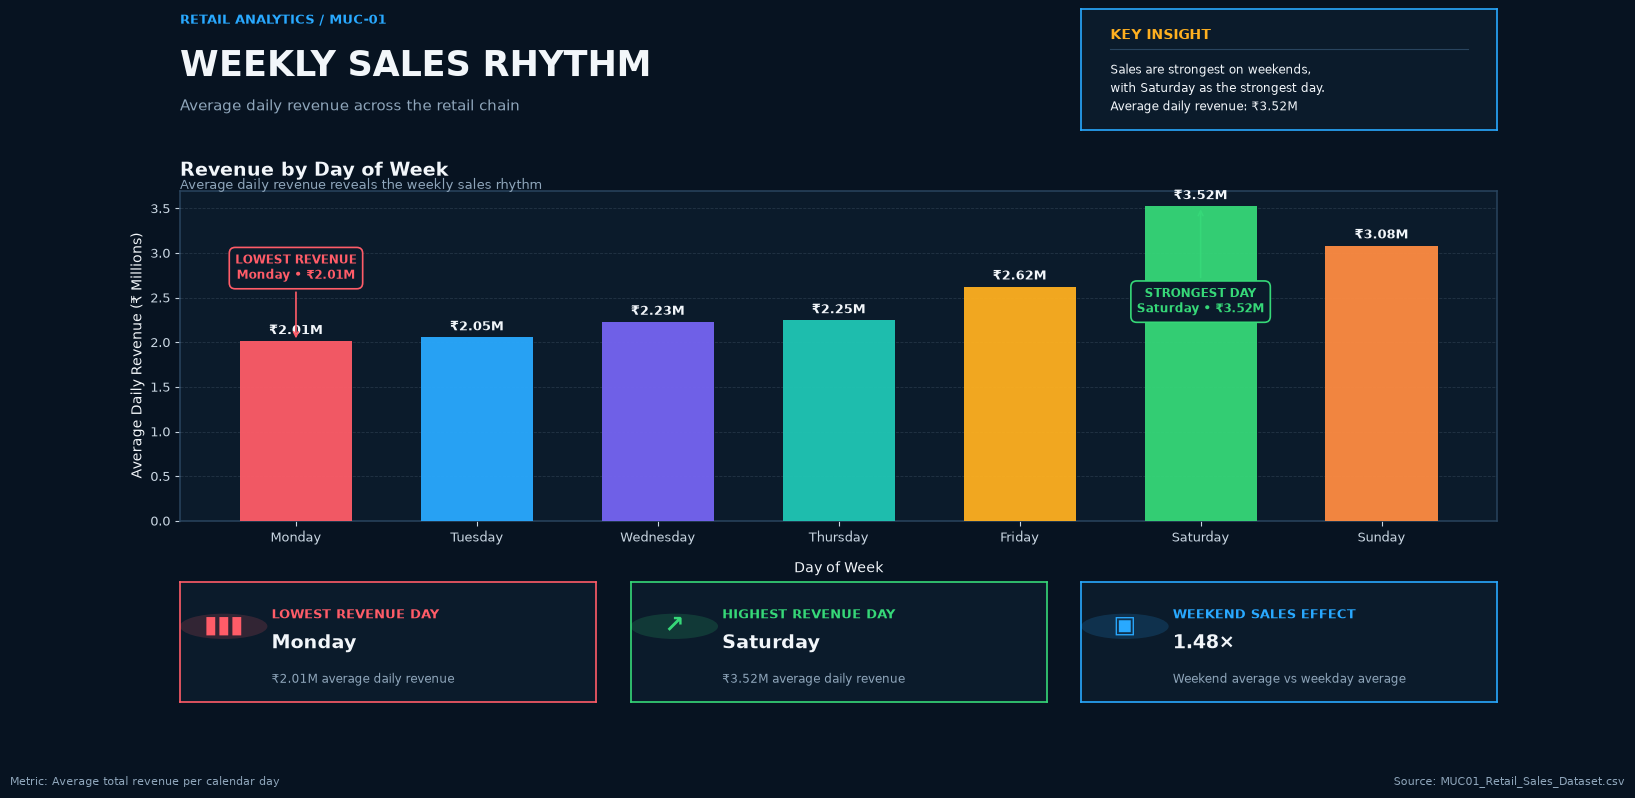

In [31]:
# ============================================================
# WEEKLY SALES RHYTHM — CLEAN EXECUTIVE VIEW
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# DATA
# ============================================================
avg_daily_revenue_by_day = avg_daily_revenue
days = avg_daily_revenue_by_day.index.tolist()
daily_values = avg_daily_revenue_by_day.values

best_day = avg_daily_revenue_by_day.idxmax()
best_day_revenue = avg_daily_revenue_by_day.max()

worst_day = avg_daily_revenue_by_day.idxmin()
worst_day_revenue = avg_daily_revenue_by_day.min()

weekday_days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

weekend_days = [
    "Saturday",
    "Sunday"
]

weekday_avg = avg_daily_revenue_by_day[
    avg_daily_revenue_by_day.index.isin(weekday_days)
].mean()

weekend_avg = avg_daily_revenue_by_day[
    avg_daily_revenue_by_day.index.isin(weekend_days)
].mean()

weekend_ratio = weekend_avg / weekday_avg


# ============================================================
# COLOR SYSTEM
# ============================================================

BG = "#071321"
PANEL = "#0B1B2B"
TEXT = "#F2F6FA"
MUTED = "#8FA6BB"
BORDER = "#29445E"

RED = "#FF5C68"
BLUE = "#29A9FF"
PURPLE = "#7564F2"
TEAL = "#20C7B5"
YELLOW = "#FFB020"
GREEN = "#36D878"
ORANGE = "#FF8C42"

day_colors = [
    RED,
    BLUE,
    PURPLE,
    TEAL,
    YELLOW,
    GREEN,
    ORANGE
]


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(17, 9),
    facecolor=BG
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=6,
    height_ratios=[1.55, 4.25, 1.55],
    hspace=0.32,
    wspace=0.18
)


# ============================================================
# HEADER — LEFT
# ============================================================

header = fig.add_subplot(gs[0, 0:4])

header.set_facecolor(BG)
header.set_xticks([])
header.set_yticks([])

for spine in header.spines.values():
    spine.set_visible(False)


# Small label
header.text(
    0.0,
    0.88,
    "RETAIL ANALYTICS / MUC-01",
    fontsize=9,
    fontweight="bold",
    color=BLUE,
    transform=header.transAxes
)


# Main title
header.text(
    0.0,
    0.52,
    "WEEKLY SALES RHYTHM",
    fontsize=25,
    fontweight="bold",
    color=TEXT,
    transform=header.transAxes,
    va="center"
)


# Subtitle
header.text(
    0.0,
    0.16,
    "Average daily revenue across the retail chain",
    fontsize=10.5,
    color=MUTED,
    transform=header.transAxes
)


# ============================================================
# KEY INSIGHT — SEPARATE HEADER PANEL
# ============================================================

key_ax = fig.add_subplot(gs[0, 4:6])

key_ax.set_facecolor(PANEL)

key_ax.set_xticks([])
key_ax.set_yticks([])

for spine in key_ax.spines.values():
    spine.set_color(BLUE)
    spine.set_linewidth(1.2)


# Title
key_ax.text(
    0.07,
    0.84,
    "KEY INSIGHT",
    fontsize=10,
    fontweight="bold",
    color=YELLOW,
    transform=key_ax.transAxes,
    va="top"
)


# Separator
key_ax.plot(
    [0.07, 0.93],
    [0.67, 0.67],
    color=BORDER,
    linewidth=0.8,
    transform=key_ax.transAxes
)


# Insight
key_ax.text(
    0.07,
    0.57,
     "Sales are strongest on weekends,\n"
     f"with {best_day} as the strongest day.\n"
     f"Average daily revenue: ₹{best_day_revenue/1_000_000:.2f}M",
    fontsize=8.8,
    color=TEXT,
    transform=key_ax.transAxes,
    va="top",
    linespacing=1.5
)


# ============================================================
# MAIN BAR CHART
# ============================================================

ax = fig.add_subplot(gs[1, :])

ax.set_facecolor(PANEL)


bars = ax.bar(
    days,
    daily_values / 1_000_000,
    color=day_colors,
    width=0.62,
    alpha=0.95,
    zorder=3
)


# ============================================================
# VALUE LABELS
# ============================================================

for bar, value in zip(
    bars,
    daily_values / 1_000_000
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.045,
        f"₹{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=TEXT,
        zorder=5
    )


# ============================================================
# CHART TITLE
# ============================================================

ax.text(
    0.0,
    1.045,
    "Revenue by Day of Week",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    color=TEXT
)

ax.text(
    0.0,
    1.005,
    "Average daily revenue reveals the weekly sales rhythm",
    transform=ax.transAxes,
    fontsize=9,
    color=MUTED
)


# ============================================================
# LOWEST DAY CALLOUT
# ============================================================

worst_index = days.index(worst_day)

ax.annotate(
    f"LOWEST REVENUE\n"
    f"{worst_day} • ₹{worst_day_revenue/1_000_000:.2f}M",

    xy=(
        worst_index,
        worst_day_revenue / 1_000_000
    ),

    xytext=(0, 42),

    textcoords="offset points",

    ha="center",
    va="bottom",

    fontsize=8.5,
    fontweight="bold",

    color=RED,

    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor=PANEL,
        edgecolor=RED,
        linewidth=1.2
    ),

    arrowprops=dict(
        arrowstyle="->",
        color=RED,
        linewidth=1.2
    ),

    zorder=10
)


# ============================================================
# STRONGEST DAY CALLOUT
# IMPORTANT: KEEP IT INSIDE THE CHART
# ============================================================

best_index = days.index(best_day)

ax.annotate(
    f"STRONGEST DAY\n"
    f"{best_day} • ₹{best_day_revenue/1_000_000:.2f}M",

    xy=(
        best_index,
        best_day_revenue / 1_000_000
    ),

    # Move callout DOWN instead of into header
    xytext=(0, -58),

    textcoords="offset points",

    ha="center",
    va="top",

    fontsize=8.5,
    fontweight="bold",

    color=GREEN,

    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor=PANEL,
        edgecolor=GREEN,
        linewidth=1.2
    ),

    arrowprops=dict(
        arrowstyle="->",
        color=GREEN,
        linewidth=1.2
    ),

    zorder=10
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Day of Week",
    fontsize=10,
    color=TEXT,
    labelpad=12
)

ax.set_ylabel(
    "Average Daily Revenue (₹ Millions)",
    fontsize=10,
    color=TEXT
)


# ============================================================
# TICKS
# ============================================================

ax.tick_params(
    axis="x",
    colors="#C9D6E2",
    labelsize=9
)

ax.tick_params(
    axis="y",
    colors="#C9D6E2",
    labelsize=9
)


# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color=MUTED
)

ax.set_axisbelow(True)


# ============================================================
# CHART BORDER
# ============================================================

for spine in ax.spines.values():
    spine.set_color(BORDER)
    spine.set_linewidth(1.1)


# ============================================================
# INSIGHT CARD FUNCTION
# ============================================================

def create_insight_card(
    card_ax,
    icon,
    title,


    
    main_value,
    description,
    accent
):

    card_ax.set_facecolor(PANEL)

    for spine in card_ax.spines.values():
        spine.set_color(accent)
        spine.set_linewidth(1.2)

    card_ax.set_xticks([])
    card_ax.set_yticks([])


    # Icon circle
    circle = Circle(
        (0.105, 0.63),
        0.105,
        transform=card_ax.transAxes,
        facecolor=accent,
        alpha=0.16,
        edgecolor="none"
    )

    card_ax.add_patch(circle)


    # Icon
    card_ax.text(
        0.105,
        0.63,
        icon,
        transform=card_ax.transAxes,
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=accent
    )


    # Heading
    card_ax.text(
        0.22,
        0.78,
        title,
        transform=card_ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        color=accent,
        va="top"
    )


    # Main value
    card_ax.text(
        0.22,
        0.49,
        main_value,
        transform=card_ax.transAxes,
        fontsize=14,
        fontweight="bold",
        color=TEXT,
        va="center"
    )


    # Description
    card_ax.text(
        0.22,
        0.19,
        description,
        transform=card_ax.transAxes,
        fontsize=8.3,
        color=MUTED,
        va="center"
    )


# ============================================================
# CARD 1 — LOWEST DAY
# ============================================================

card1 = fig.add_subplot(gs[2, 0:2])

create_insight_card(
    card1,
    "▮▮▮",
    "LOWEST REVENUE DAY",
    worst_day,
    f"₹{worst_day_revenue/1_000_000:.2f}M average daily revenue",
    RED
)


# ============================================================
# CARD 2 — HIGHEST DAY
# ============================================================

card2 = fig.add_subplot(gs[2, 2:4])

create_insight_card(
    card2,
    "↗",
    "HIGHEST REVENUE DAY",
    best_day,
    f"₹{best_day_revenue/1_000_000:.2f}M average daily revenue",
    GREEN
)


# ============================================================
# CARD 3 — WEEKEND EFFECT
# ============================================================

card3 = fig.add_subplot(gs[2, 4:6])

create_insight_card(
    card3,
    "▣",
    "WEEKEND SALES EFFECT",
    f"{weekend_ratio:.2f}×",
    "Weekend average vs weekday average",
    BLUE
)


# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.025,
    0.018,
    "Metric: Average total revenue per calendar day",
    fontsize=8,
    color=MUTED
)

fig.text(
    0.975,
    0.018,
    "Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color=MUTED,
    ha="right"
)


# ============================================================
# DISPLAY
# ============================================================

plt.show()

### What We Found

**Saturday is the strongest sales day**, with an average daily revenue of approximately **₹3.52M**, while **Monday is the weakest**, at approximately **₹2.01M**. Revenue generally increases toward the weekend, with Saturday and Sunday showing higher average daily revenue than the other days. The weekend average is about **1.48× the weekday average**, suggesting that weekends may be important periods for promotional activities.

### c Monthly Revenue Pattern
### Why are we checking this?

We want to understand how total revenue changes from month to month across the six-month period. This helps identify the strongest and weakest months for the retail chain and supports better planning of promotions and sales activities.


In [35]:
# Calculate total revenue by month

monthly_chain_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["revenue"]
      .sum()
)

monthly_chain_revenue

date
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Freq: M, Name: revenue, dtype: float64

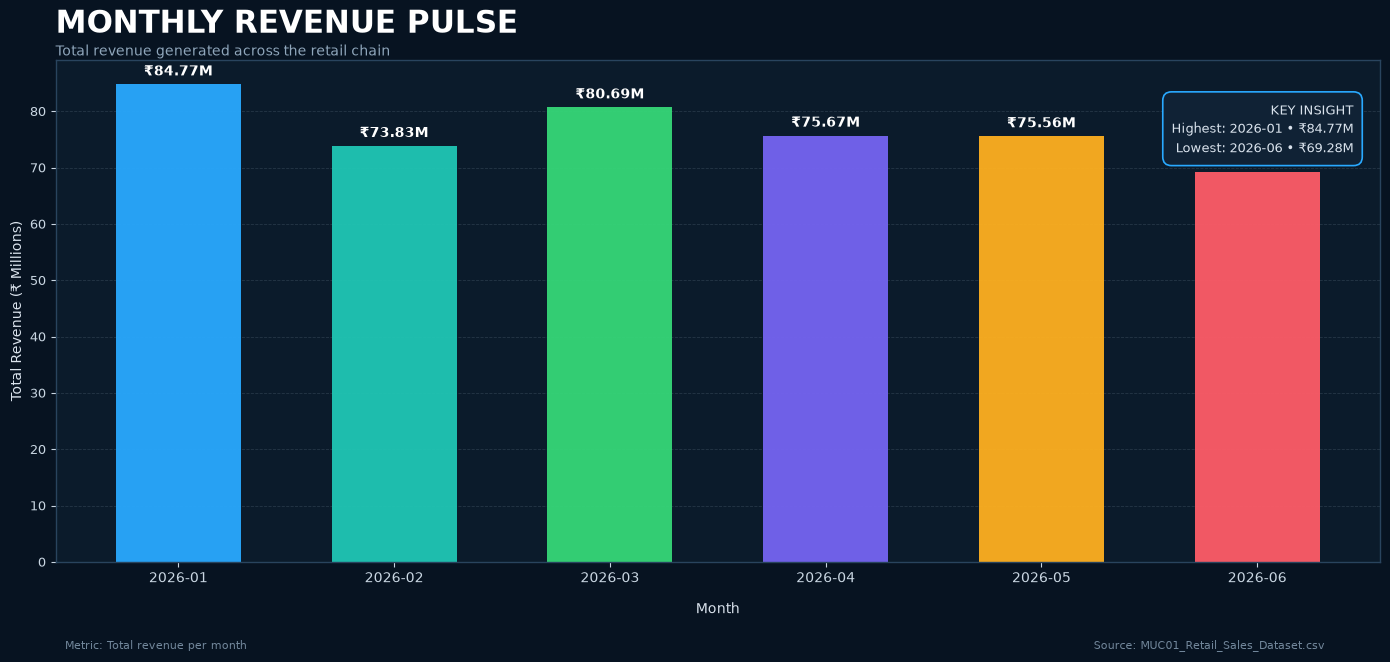

In [36]:
# ============================================================
# MONTHLY REVENUE — EXECUTIVE VIEW
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

months = monthly_chain_revenue.index.astype(str)
monthly_values = monthly_chain_revenue.values / 1_000_000

best_month = months[monthly_values.argmax()]
best_month_value = monthly_values.max()

worst_month = months[monthly_values.argmin()]
worst_month_value = monthly_values.min()

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 7),
    facecolor="#071321"
)

ax.set_facecolor("#0B1B2B")

# ------------------------------------------------------------
# BARS
# ------------------------------------------------------------

bars = ax.bar(
    months,
    monthly_values,
    width=0.58,
    color=[
        "#29A9FF",
        "#20C7B5",
        "#36D878",
        "#7564F2",
        "#FFB020",
        "#FF5C68"
    ],
    alpha=0.95
)

# ------------------------------------------------------------
# VALUE LABELS
# ------------------------------------------------------------

for bar, value in zip(bars, monthly_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"₹{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ax.set_title(
    "MONTHLY REVENUE PULSE",
    fontsize=22,
    fontweight="bold",
    color="white",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.01,
    "Total revenue generated across the retail chain",
    transform=ax.transAxes,
    fontsize=10,
    color="#8FA6BB"
)

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Month",
    fontsize=10,
    color="#D9E2EC",
    labelpad=12
)

ax.set_ylabel(
    "Total Revenue (₹ Millions)",
    fontsize=10,
    color="#D9E2EC"
)

ax.tick_params(
    axis="x",
    colors="#C9D6E2",
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors="#C9D6E2",
    labelsize=9
)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color="#9FB3C8"
)

ax.set_axisbelow(True)

# ------------------------------------------------------------
# BORDER
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_color("#29445E")
    spine.set_linewidth(1)

# ------------------------------------------------------------
# KEY INSIGHT
# ------------------------------------------------------------

ax.text(
    0.98,
    0.92,
    "KEY INSIGHT\n"
    f"Highest: {best_month} • ₹{best_month_value:.2f}M\n"
    f"Lowest: {worst_month} • ₹{worst_month_value:.2f}M",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color="#D9E2EC",
    linespacing=1.5,
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#102235",
        edgecolor="#29A9FF",
        linewidth=1.2
    )
)

# ------------------------------------------------------------
# FOOTNOTE
# ------------------------------------------------------------

fig.text(
    0.05,
    0.025,
    "Metric: Total revenue per month",
    fontsize=8,
    color="#71869A"
)

fig.text(
    0.95,
    0.025,
    "Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color="#71869A",
    ha="right"
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.05, 1, 0.96]
)

plt.show()

### What We Found

**January is the strongest revenue month**, with total chain revenue of approximately **₹84.77M**, while **June is the weakest**, at approximately **₹69.28M**. Revenue moves up and down during the six-month period, but the overall level is lower in June than in January. This shows that the retail chain experienced weaker revenue toward the end of the analysis period.

### d Electronics — Day-of-Week Performance
### Why are we checking this?

Electronics showed the steepest revenue decline among the five categories. We therefore want to check whether Electronics follows the same weekly sales pattern as the overall retail chain or has a different pattern. This can help identify suitable days for category-level promotional activities.

In [37]:
# Filter Electronics transactions

electronics_df = df[df["category"] == "Electronics"].copy()

# Calculate total Electronics revenue for each actual date

electronics_daily_revenue = (
    electronics_df.groupby("date")["revenue"]
    .sum()
    .reset_index()
)

# Add day of week

electronics_daily_revenue["day_of_week"] = (
    electronics_daily_revenue["date"].dt.day_name()
)

# Order the days correctly

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Calculate average daily Electronics revenue by weekday

electronics_avg_daily_revenue = (
    electronics_daily_revenue
    .groupby("day_of_week")["revenue"]
    .mean()
    .reindex(day_order)
)

electronics_avg_daily_revenue

day_of_week
Monday       9.709755e+05
Tuesday      9.754327e+05
Wednesday    1.111579e+06
Thursday     1.061518e+06
Friday       1.291064e+06
Saturday     1.786658e+06
Sunday       1.558130e+06
Name: revenue, dtype: float64

### What We Found

**Saturday is the strongest day for Electronics**, with average daily revenue of approximately **₹1.79M**, while **Monday is the weakest**, at approximately **₹0.97M**. Electronics revenue increases toward the weekend, following a pattern similar to the overall retail chain. This suggests that weekend periods may also be important for Electronics-focused promotional activities.

### e Electronics — Monthly Revenue
### Why are we checking this?

We want to see how Electronics revenue changed month by month during the six-month period. This helps us compare the category's monthly pattern with the overall retail chain and understand where the decline became more noticeable.

In [38]:
# Calculate monthly Electronics revenue

electronics_monthly_revenue = (
    electronics_df
    .groupby(electronics_df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

electronics_monthly_revenue

date
2026-01    45686596.63
2026-02    38988602.50
2026-03    40846509.47
2026-04    37092265.09
2026-05    34226926.43
2026-06    29686824.81
Freq: M, Name: revenue, dtype: float64

### What We Found

**January is the strongest month for Electronics**, with revenue of approximately **₹45.69M**, while **June is the weakest**, at approximately **₹29.69M**. Electronics revenue decreases overall during the six-month period, with some ups and downs between individual months. The category's decline toward June is consistent with the **35.0% January-to-June decline** identified in Step 6.2.

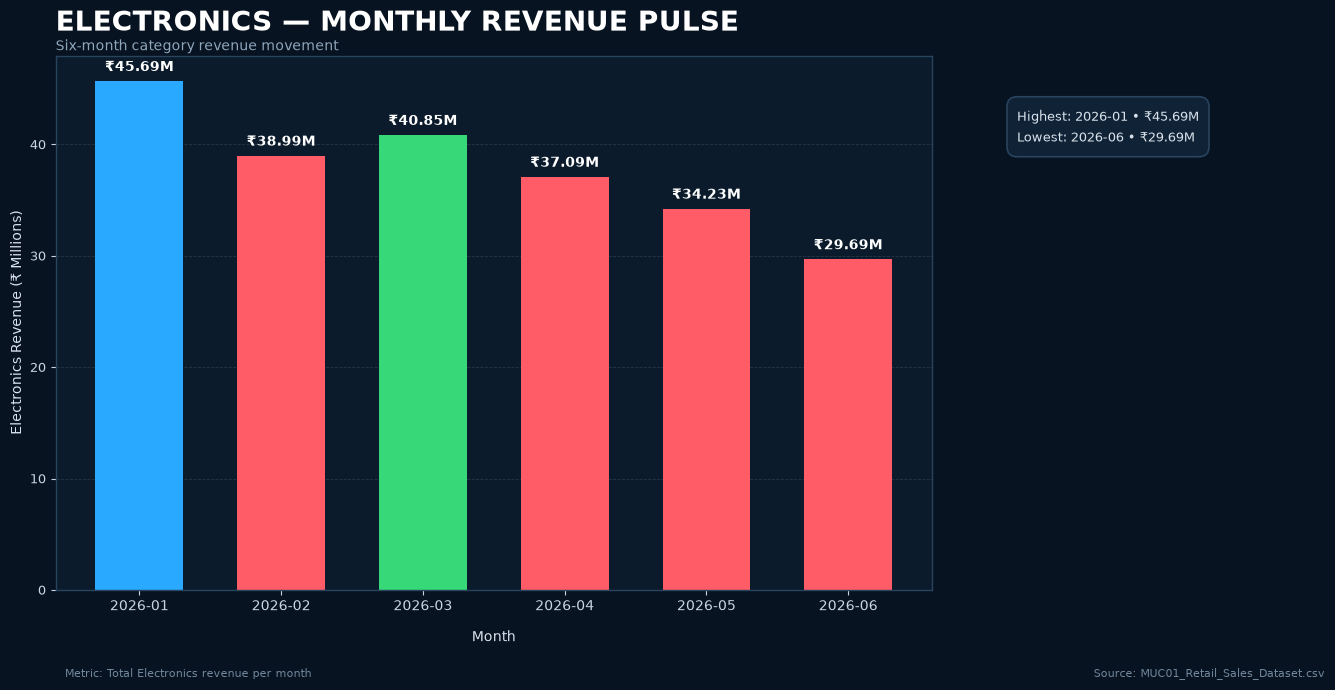

In [39]:
# ============================================================
# ELECTRONICS — MONTHLY REVENUE TREND
# ============================================================

electronics_monthly = (
    df[df["category"] == "Electronics"]
    .groupby(df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

months = electronics_monthly.index.astype(str)
values = electronics_monthly.values / 1_000_000

best_month = months[values.argmax()]
best_value = values.max()

worst_month = months[values.argmin()]
worst_value = values.min()

# Month-to-month direction
colors = []

for i in range(len(values)):
    if i == 0:
        colors.append("#29A9FF")
    elif values[i] >= values[i - 1]:
        colors.append("#36D878")
    else:
        colors.append("#FF5C68")

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7),
    facecolor="#071321"
)

ax.set_facecolor("#0B1B2B")

bars = ax.bar(
    months,
    values,
    color=colors,
    width=0.62
)

# ============================================================
# VALUE LABELS
# ============================================================

for bar, value in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"₹{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "ELECTRONICS — MONTHLY REVENUE PULSE",
    fontsize=20,
    fontweight="bold",
    color="white",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.01,
    "Six-month category revenue movement",
    transform=ax.transAxes,
    fontsize=10,
    color="#8FA6BB"
)

# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    "Month",
    fontsize=10,
    color="#D9E2EC",
    labelpad=12
)

ax.set_ylabel(
    "Electronics Revenue (₹ Millions)",
    fontsize=10,
    color="#D9E2EC"
)

ax.tick_params(
    axis="x",
    colors="#C9D6E2",
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors="#C9D6E2",
    labelsize=9
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18,
    color="#9FB3C8"
)

ax.set_axisbelow(True)

# ============================================================
# BORDER
# ============================================================

for spine in ax.spines.values():
    spine.set_color("#29445E")
    spine.set_linewidth(1)

# ============================================================
# KEY INSIGHT PANEL
# ============================================================

fig.text(
    0.73,
    0.84,
    "CATEGORY SIGNAL",
    fontsize=9,
    fontweight="bold",
    color="#FFB020",
    ha="left"
)

fig.text(
    0.73,
    0.79,
    f"Highest: {best_month} • ₹{best_value:.2f}M\n"
    f"Lowest: {worst_month} • ₹{worst_value:.2f}M",
    fontsize=9,
    color="#D9E2EC",
    ha="left",
    linespacing=1.6,
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#102235",
        edgecolor="#29445E",
        linewidth=1.2
    )
)

# ============================================================
# FOOTNOTES
# ============================================================

fig.text(
    0.05,
    0.025,
    "Metric: Total Electronics revenue per month",
    fontsize=8,
    color="#71869A"
)

fig.text(
    0.95,
    0.025,
    "Source: MUC01_Retail_Sales_Dataset.csv",
    fontsize=8,
    color="#71869A",
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.05, 0.68, 1]
)

plt.show()

### f Electronics vs Retail Chain
## Why are we checking this?

We want to compare Electronics with the overall retail chain to see whether the category follows the same day-of-week and monthly patterns as the business. This comparison helps determine whether the Electronics decline is part of the wider chain pattern or is more specific to the category.

In [40]:
# Compare chain and Electronics performance

comparison = pd.DataFrame({
    "Metric": [
        "Strongest Day",
        "Weakest Day",
        "Strongest Month",
        "Weakest Month"
    ],
    "Retail Chain": [
        avg_daily_revenue.idxmax(),
        avg_daily_revenue.idxmin(),
        monthly_chain_revenue.idxmax().strftime("%Y-%m"),
        monthly_chain_revenue.idxmin().strftime("%Y-%m")
    ],
    "Electronics": [
        electronics_avg_daily_revenue.idxmax(),
        electronics_avg_daily_revenue.idxmin(),
        electronics_monthly_revenue.idxmax().strftime("%Y-%m"),
        electronics_monthly_revenue.idxmin().strftime("%Y-%m")
    ]
})

comparison

,Metric,Retail Chain,Electronics
0,Strongest Day,Saturday,Saturday
1,Weakest Day,Monday,Monday
2,Strongest Month,2026-01,2026-01
3,Weakest Month,2026-06,2026-06


### What We Found

Electronics follows the same key timing pattern as the overall retail chain: **Saturday is the strongest day and Monday is the weakest day**, while **January is the strongest month and June is the weakest month** for both. This shows that Electronics follows the chain's weekly and monthly sales rhythm, but its overall decline is more pronounced, with revenue falling from **₹45.69M in January to ₹29.69M in June**.

### Promotional Timing

The analysis shows that **weekends, particularly Saturday, are the strongest sales period** for both the retail chain and Electronics, so promotions could be considered around the weekend. Since June is the weakest month and Electronics shows a continued decline toward June, additional promotional activity could also be considered during weaker periods. The effectiveness of such promotions should be evaluated using future sales, margin, and promotion data.

------------

## 6 Category Manager Briefing
#### a Identify the strongest category
### Why are we checking this?

We want to identify which category contributes the most revenue over the six-month period. This provides the Category Manager with a starting point for discussing investment priorities during the supplier review.


In [41]:
# Calculate total revenue by category

category_total_revenue = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_total_revenue

category
Electronics       2.265277e+08
Home & Kitchen    8.184572e+07
Apparel           6.947959e+07
Grocery           4.230258e+07
Personal Care     3.964856e+07
Name: revenue, dtype: float64

### What We Found

**Electronics is the largest revenue-generating category**, with total six-month revenue of approximately **₹226.53M**. Home & Kitchen follows with approximately **₹81.85M**, while Apparel, Grocery, and Personal Care contribute lower total revenue. This makes Electronics an important category to consider when discussing investment and supplier performance.

### b Product to Challenge
### Why are we checking this?

We want to identify a specific product that may need attention within the key category. Using a product-level revenue figure makes the supplier discussion more specific than discussing the category alone.

In [43]:
# Identify the highest-revenue product

top_product = (
    product_revenue
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

top_product

category        Electronics
product_name     Headphones
revenue         47696053.99
Name: 5, dtype: object

### What We Found

**Headphones is the highest-revenue product** in the dataset, generating approximately **₹47.70M** in total revenue over the six-month period. It belongs to the **Electronics** category, which is also the largest revenue-generating category. This makes Headphones an important product to consider when discussing Electronics performance with suppliers.

### c Discount Finding
### Why are we checking this?

We want to include the discount analysis in the final briefing because the Category Manager needs to understand whether deeper discounts were associated with higher transaction revenue or higher purchase quantities.

In [44]:
# Extract the 0% and 20% discount results

discount_0 = discount_analysis[
    discount_analysis["discount_group"] == "0%"
].iloc[0]

discount_20 = discount_analysis[
    discount_analysis["discount_group"] == "20%"
].iloc[0]

print("0% discount:")
print(f"Average revenue per transaction: ₹{discount_0['Avg_Revenue_Per_Transaction']:,.2f}")
print(f"Average units sold: {discount_0['Avg_Units_Sold']:.2f}")

print("\n20% discount:")
print(f"Average revenue per transaction: ₹{discount_20['Avg_Revenue_Per_Transaction']:,.2f}")
print(f"Average units sold: {discount_20['Avg_Units_Sold']:.2f}")

0% discount:
Average revenue per transaction: ₹4,685.65
Average units sold: 2.59

20% discount:
Average revenue per transaction: ₹3,631.73
Average units sold: 2.58


### What We Found

Average revenue per transaction decreases from **₹4,685.65 at 0% discount to ₹3,631.73 at 20% discount**, a decrease of approximately **22.5%**. At the same time, average units sold remains almost unchanged, moving from **2.59 units to 2.58 units per transaction**. This means that deeper discounts did not show a meaningful increase in purchase quantity or average transaction revenue in this dataset.


### d Additional Data Needed
### Why are we checking this?

The current dataset shows sales transactions, revenue, units sold, prices and discounts, but it does not explain why revenue changed. We need one additional business data item that can help the Category Manager understand the reason behind the observed performance.
### What We Found

**Inventory and stockout data would be useful additional information.** It would help determine whether the decline in Electronics revenue was caused by lower customer demand or products being unavailable. This information would help the Category Manager have a more evidence-based discussion with suppliers.


We now combine the main findings from the analysis into a short business briefing for the Category Manager. The briefing connects category performance, product performance, discount behavior and the additional data needed for the supplier review.

### Category Manager Briefing

Electronics provides the strongest revenue case for attention, generating approximately **₹226.53M** over six months, although its revenue declined by **35.0%** from **₹45.69M in January to ₹29.69M in June**. Within Electronics, **Headphones generated approximately ₹47.70M**, making it an important product to consider during the supplier discussion. The discount analysis shows that average revenue per transaction decreased from **₹4,685.65 at 0% discount to ₹3,631.73 at 20% discount**, while average units sold remained almost unchanged at around **2.6 units**. Therefore, the available data does not show a clear revenue benefit from deeper discounts. **Inventory and stockout data** would be useful to determine whether the Electronics decline was related to product availability or customer demand.